In [19]:
import os
import json
import random
import time
import pickle
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T

warnings.filterwarnings('ignore')
%matplotlib inline

In [20]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_DIR      = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed'
MODELS_DIR    = BASE_DIR / 'models'
RESULTS_DIR   = BASE_DIR / 'results'
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB


In [21]:
manifest_path = PROCESSED_DIR / 'data_manifest.pkl'
assert manifest_path.exists(), 'Run data-preprocessing.ipynb first!'

with open(manifest_path, 'rb') as f:
    manifest = pickle.load(f)

train_samples = [(Path(p), lbl) for p, lbl in manifest['train']]
val_samples   = [(Path(p), lbl) for p, lbl in manifest['val']]
CLASS_MAP     = manifest['class_map']
MEAN          = tuple(manifest['mean'])
STD           = tuple(manifest['std'])
NUM_CLASSES   = manifest['num_classes']

print(f'Train : {len(train_samples):,} | Val : {len(val_samples):,} | Classes : {NUM_CLASSES}')

Train : 100,000 | Val : 10,000 | Classes : 200


In [22]:
TRAIN_TRANSFORM = T.Compose([
    T.RandomCrop(64, padding=8, padding_mode='reflect'),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.RandomErasing(p=0.2, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0),
    T.Normalize(mean=MEAN, std=STD),
])

VAL_TRANSFORM = T.Compose([
    T.CenterCrop(56),
    T.Resize(64, interpolation=T.InterpolationMode.BILINEAR, antialias=True),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

In [23]:
class TinyImageNetTrain(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return TRAIN_TRANSFORM(Image.open(path).convert('RGB')), label


class TinyImageNetVal(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return VAL_TRANSFORM(Image.open(path).convert('RGB')), label

In [24]:
NUM_WORKERS = min(6, max(1, (os.cpu_count() or 4) - 1))

train_loader = DataLoader(
    TinyImageNetTrain(train_samples),
    batch_size=128, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True, prefetch_factor=2, drop_last=True,
)
val_loader = DataLoader(
    TinyImageNetVal(val_samples),
    batch_size=256, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True, prefetch_factor=2,
)

print(f'Train batches : {len(train_loader)} | Val batches : {len(val_loader)}')

Train batches : 781 | Val batches : 40


In [25]:
DRY_RUN             = True
DRY_SUPERNET_EPOCHS = 2
DRY_BATCHES         = 10
DRY_VAL_BATCHES     = 5
DRY_GENERATIONS     = 2
DRY_POPULATION      = 6

print(f'DRY_RUN = {DRY_RUN}')

OP_NAMES = [
    'identity',       # 0
    'dwconv3x3',      # 1
    'dwconv5x5',      # 2
    'mbconv3x3',      # 3
    'mbconv5x5',      # 4
    'shuffle_block',  # 5
    'se_block',       # 6
]
NUM_OPS = len(OP_NAMES)

CELL_CONFIG = [
    (32,  1), (32,  1), (64,  2),
    (64,  1), (64,  1), (128, 2),
    (128, 1), (128, 1), (128, 1),
    (128, 1), (192, 2), (192, 1),
    (192, 1), (192, 1), (256, 2),
    (256, 1), (256, 1), (256, 1),
    (256, 1), (256, 1),
]
NUM_CELLS = len(CELL_CONFIG)   # 20
STEM_CH   = 32

print(f'Search space: {NUM_OPS} ops × {NUM_CELLS} cells  →  {NUM_OPS**NUM_CELLS:.2e} architectures')

DRY_RUN = True
Search space: 7 ops × 20 cells  →  7.98e+16 architectures


In [26]:
class DepthwiseSepConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride=1):
        super().__init__()
        pad = kernel_size // 2
        self.op = nn.Sequential(
            nn.Conv2d(C_in, C_in, kernel_size, stride=stride,
                      padding=pad, groups=C_in, bias=False),
            nn.BatchNorm2d(C_in), nn.ReLU6(inplace=True),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out), nn.ReLU6(inplace=True),
        )

    def forward(self, x): return self.op(x)


class MBConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride=1, expand_ratio=3):
        super().__init__()
        v   = C_in * expand_ratio
        mid = max(8, int(v + 8 / 2) // 8 * 8)
        pad = kernel_size // 2
        self.use_res = (stride == 1) and (C_in == C_out)
        self.op = nn.Sequential(
            nn.Conv2d(C_in, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU6(inplace=True),
            nn.Conv2d(mid, mid, kernel_size, stride=stride,
                      padding=pad, groups=mid, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU6(inplace=True),
            nn.Conv2d(mid, C_out, 1, bias=False), nn.BatchNorm2d(C_out),
        )

    def forward(self, x):
        out = self.op(x)
        return x + out if self.use_res else out


class ShuffleBlock(nn.Module):
    def __init__(self, C_in, C_out, stride=1):
        super().__init__()
        branch = C_out // 2
        if stride > 1:
            self.branch1 = nn.Sequential(
                nn.Conv2d(C_in, C_in, 3, stride=stride, padding=1, groups=C_in, bias=False),
                nn.BatchNorm2d(C_in),
                nn.Conv2d(C_in, branch, 1, bias=False), nn.BatchNorm2d(branch), nn.ReLU(inplace=True),
            )
            self.branch2 = nn.Sequential(
                nn.Conv2d(C_in, branch, 1, bias=False), nn.BatchNorm2d(branch), nn.ReLU(inplace=True),
                nn.Conv2d(branch, branch, 3, stride=stride, padding=1, groups=branch, bias=False),
                nn.BatchNorm2d(branch),
                nn.Conv2d(branch, branch, 1, bias=False), nn.BatchNorm2d(branch), nn.ReLU(inplace=True),
            )
        else:
            self.branch1 = nn.Identity()
            half = C_in // 2
            self.branch2 = nn.Sequential(
                nn.Conv2d(half, branch, 1, bias=False), nn.BatchNorm2d(branch), nn.ReLU(inplace=True),
                nn.Conv2d(branch, branch, 3, padding=1, groups=branch, bias=False),
                nn.BatchNorm2d(branch),
                nn.Conv2d(branch, branch, 1, bias=False), nn.BatchNorm2d(branch), nn.ReLU(inplace=True),
            )
        self.stride = stride

    def _shuffle(self, x, groups=2):
        B, C, H, W = x.shape
        return x.view(B, groups, C // groups, H, W).transpose(1, 2).contiguous().view(B, C, H, W)

    def forward(self, x):
        if self.stride > 1:
            out = torch.cat([self.branch1(x), self.branch2(x)], dim=1)
        else:
            x1, x2 = x.chunk(2, dim=1)
            out = torch.cat([self.branch1(x1), self.branch2(x2)], dim=1)
        return self._shuffle(out)


class SEBlock(nn.Module):
    def __init__(self, C_in, C_out, stride=1, reduction=4):
        super().__init__()
        mid = max(8, C_in // reduction)
        self.use_res = (stride == 1) and (C_in == C_out)
        self.bn      = nn.BatchNorm2d(C_out)
        self.conv_dw = nn.Conv2d(C_in, C_in, 3, stride=stride, padding=1, groups=C_in, bias=False)
        self.conv_pw = nn.Conv2d(C_in, C_out, 1, bias=False)
        self.se      = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(C_out, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, C_out), nn.Sigmoid(),
        )

    def forward(self, x):
        out = F.relu6(self.conv_dw(x))
        out = self.conv_pw(out)
        se  = self.se(out).view(out.size(0), out.size(1), 1, 1)
        out = out * se
        return (out + x) if self.use_res else self.bn(out)


class Identity(nn.Module):
    def __init__(self, C_in, C_out, stride=1):
        super().__init__()
        self.adapt = nn.Identity() if (C_in == C_out and stride == 1) else \
                     nn.Sequential(nn.Conv2d(C_in, C_out, 1, stride=stride, bias=False),
                                   nn.BatchNorm2d(C_out))

    def forward(self, x): return self.adapt(x)


def build_op(op_name: str, C_in: int, C_out: int, stride: int = 1) -> nn.Module:
    if op_name == 'identity':        return Identity(C_in, C_out, stride)
    elif op_name == 'dwconv3x3':     return DepthwiseSepConv(C_in, C_out, 3, stride)
    elif op_name == 'dwconv5x5':     return DepthwiseSepConv(C_in, C_out, 5, stride)
    elif op_name == 'mbconv3x3':     return MBConv(C_in, C_out, 3, stride)
    elif op_name == 'mbconv5x5':     return MBConv(C_in, C_out, 5, stride)
    elif op_name == 'shuffle_block': return ShuffleBlock(C_in, C_out, stride)
    elif op_name == 'se_block':      return SEBlock(C_in, C_out, stride)
    else: raise ValueError(f'Unknown op: {op_name}')


print('All primitive ops defined: Identity, DepthwiseSepConv, MBConv, ShuffleBlock, SEBlock')

All primitive ops defined: Identity, DepthwiseSepConv, MBConv, ShuffleBlock, SEBlock


In [27]:
class SuperNet(nn.Module):
    """
    One-Shot Supernet: each cell has ALL ops in parallel.
    During forward, `arch` (list of op indices, length=NUM_CELLS)
    selects one path per cell.
    """
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, STEM_CH, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(STEM_CH),
            nn.ReLU6(inplace=True),
        )
        self.cells = nn.ModuleList()
        C_in = STEM_CH
        for C_out, stride in CELL_CONFIG:
            self.cells.append(nn.ModuleList([
                build_op(name, C_in, C_out, stride) for name in OP_NAMES
            ]))
            C_in = C_out

        C_final = CELL_CONFIG[-1][0]
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(p=0.2), nn.Linear(C_final, NUM_CLASSES),
        )

    def forward(self, x: torch.Tensor, arch: list) -> torch.Tensor:
        x = self.stem(x)
        for cell_ops, op_idx in zip(self.cells, arch):
            x = cell_ops[op_idx](x)
        return self.head(x)

    def random_arch(self) -> list:
        return [random.randint(0, NUM_OPS - 1) for _ in range(NUM_CELLS)]


supernet = SuperNet().to(DEVICE)
n_params = sum(p.numel() for p in supernet.parameters() if p.requires_grad)
print(f'SuperNet parameters : {n_params / 1e6:.2f} M')

SuperNet parameters : 10.20 M


In [28]:
lut_path = RESULTS_DIR / 'latency_lut.json'

if lut_path.exists():
    with open(lut_path) as f:
        lut = json.load(f)
    print(f'Loaded existing LUT from {lut_path.name}')
else:
    print('[LUT] Building latency lookup table …')
    lut = {}
    C_in = STEM_CH
    for cell_idx, (C_out, stride) in enumerate(CELL_CONFIG):
        lut[str(cell_idx)] = {}
        # Compute approximate spatial resolution at this cell
        spatial = 64
        for i in range(cell_idx):
            if CELL_CONFIG[i][1] == 2:
                spatial //= 2
        dummy = torch.randn(1, C_in, max(1, spatial), max(1, spatial), device=DEVICE)

        for op_idx, op_name in enumerate(OP_NAMES):
            op = build_op(op_name, C_in, C_out, stride).to(DEVICE).eval()
            latencies = []
            with torch.no_grad():
                for _ in range(10):   # warm-up
                    _ = op(dummy)
                if DEVICE.type == 'cuda':
                    torch.cuda.synchronize()
                for _ in range(50):
                    t0 = time.perf_counter()
                    _ = op(dummy)
                    if DEVICE.type == 'cuda':
                        torch.cuda.synchronize()
                    latencies.append((time.perf_counter() - t0) * 1000)
            lut[str(cell_idx)][str(op_idx)] = round(float(np.median(latencies)), 4)
            del op

        C_in = C_out
        if cell_idx % 5 == 0:
            print(f'  Cell {cell_idx:2d}/{NUM_CELLS - 1} done')

    with open(lut_path, 'w') as f:
        json.dump(lut, f, indent=2)
    print(f'✓  LUT saved → {lut_path}')

print(f'LUT covers {len(lut)} cells × {NUM_OPS} ops')

Loaded existing LUT from latency_lut.json
LUT covers 20 cells × 7 ops


In [29]:
def predict_latency(arch: list) -> float:
    """Predict total latency (ms) from the LUT for a given architecture."""
    return sum(
        lut.get(str(ci), {}).get(str(oi), 0.5)
        for ci, oi in enumerate(arch)
    )


test_arch = [0] * NUM_CELLS
print(f'Predicted latency (all-identity arch): {predict_latency(test_arch):.2f} ms')

Predicted latency (all-identity arch): 0.58 ms


In [30]:
HW_CFG = dict(
    supernet_epochs = 30,
    batch_size      = 128,
    lr              = 5e-4,
    weight_decay    = 1e-4,
    label_smoothing = 0.10,
    latency_budget  = 5.0,    
    lambda_lat      = 0.01,   
    grad_clip       = 5.0,
    early_layers    = list(range(0, 10)),
    late_layers     = list(range(10, 20)),
)

print('HW_CFG:', json.dumps({k: v for k, v in HW_CFG.items() if not isinstance(v, list)}, indent=2))

HW_CFG: {
  "supernet_epochs": 30,
  "batch_size": 128,
  "lr": 0.0005,
  "weight_decay": 0.0001,
  "label_smoothing": 0.1,
  "latency_budget": 5.0,
  "lambda_lat": 0.01,
  "grad_clip": 5.0
}


In [31]:
supernet_ckpt = MODELS_DIR / 'supernet_final.pth'

if supernet_ckpt.exists():
    ckpt = torch.load(supernet_ckpt, map_location=DEVICE, weights_only=False)
    supernet.load_state_dict(ckpt['state_dict'], strict=False)
    supernet_history = ckpt.get('history', {})
    print(f'✓  Loaded supernet from {supernet_ckpt.name}')
else:
    print(f"\n{'='*60}\n  Supernet Training (One-Shot NAS)\n{'='*60}")

    criterion = nn.CrossEntropyLoss(label_smoothing=HW_CFG['label_smoothing'])
    optimizer = optim.AdamW(supernet.parameters(),
                             lr=HW_CFG['lr'], weight_decay=HW_CFG['weight_decay'])
    n_epochs  = DRY_SUPERNET_EPOCHS if DRY_RUN else HW_CFG['supernet_epochs']
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    scaler    = GradScaler(device=DEVICE.type)
    supernet_history = {'train_loss': [], 'val_acc1': []}

    for epoch in range(1, n_epochs + 1):
        supernet.train()
        t0, run_loss, total = time.time(), 0., 0

        for batch_idx, (imgs, labels) in enumerate(train_loader):
            if DRY_RUN and batch_idx >= DRY_BATCHES:
                break
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # Progressive path sampling: only late layers are random in early epochs
            if epoch <= HW_CFG['supernet_epochs'] // 2:
                arch = [0] * NUM_CELLS
                for i in HW_CFG['late_layers']:
                    arch[i] = random.randint(0, NUM_OPS - 1)
            else:
                arch = supernet.random_arch()

            lat_penalty = max(0.0, predict_latency(arch) - HW_CFG['latency_budget'])

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=DEVICE.type):
                out  = supernet(imgs, arch)
                loss = criterion(out, labels) + HW_CFG['lambda_lat'] * lat_penalty

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(supernet.parameters(), HW_CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()

            run_loss += loss.item() * imgs.size(0)
            total    += imgs.size(0)

        scheduler.step()

        # Validation
        supernet.eval()
        correct, n_val = 0, 0
        with torch.no_grad():
            for batch_idx, (imgs, labels) in enumerate(val_loader):
                if DRY_RUN and batch_idx >= DRY_VAL_BATCHES:
                    break
                imgs   = imgs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                with autocast(device_type=DEVICE.type):
                    out = supernet(imgs, supernet.random_arch())
                correct += (out.argmax(1) == labels).sum().item()
                n_val   += labels.size(0)

        val_acc1 = correct / n_val
        supernet_history['train_loss'].append(run_loss / total)
        supernet_history['val_acc1'].append(val_acc1)
        print(f"  Epoch [{epoch:02d}/{n_epochs}]  "
              f"Loss={run_loss/total:.4f}  ValAcc@1={val_acc1*100:.2f}%  "
              f"t={time.time()-t0:.1f}s")

    torch.save({'state_dict': supernet.state_dict(), 'history': supernet_history},
               supernet_ckpt)
    print(f'✓  Supernet saved → {supernet_ckpt}')

✓  Loaded supernet from supernet_final.pth


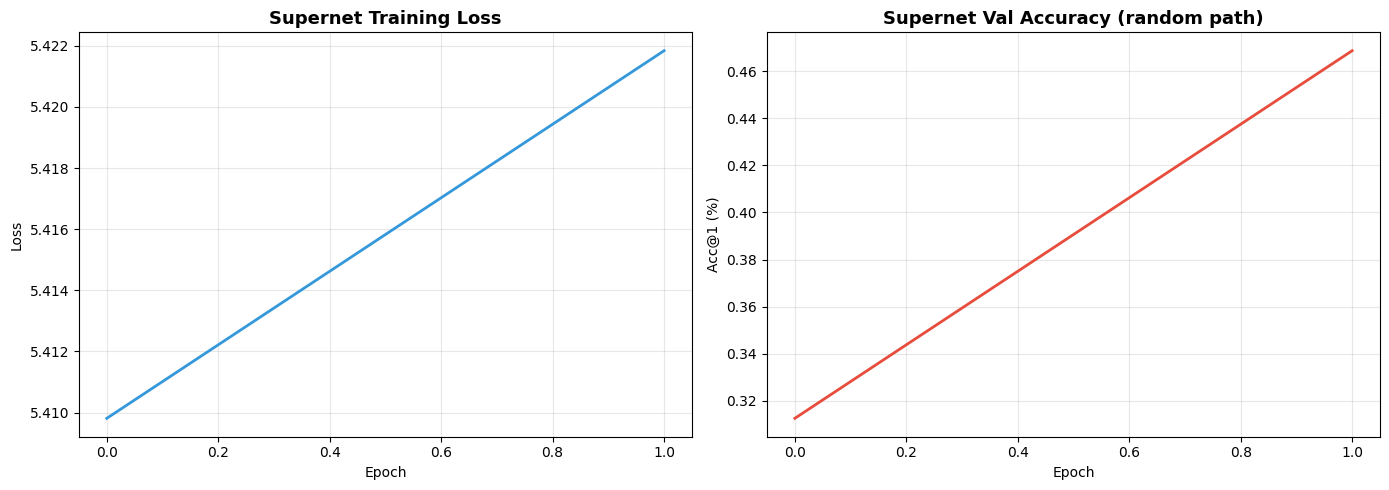

Saved → supernet_training.png


In [32]:
if supernet_history.get('train_loss'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(supernet_history['train_loss'], color='#3498DB', lw=2)
    axes[0].set_title('Supernet Training Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

    axes[1].plot([v * 100 for v in supernet_history['val_acc1']], color='#E74C3C', lw=2)
    axes[1].set_title('Supernet Val Accuracy (random path)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc@1 (%)'); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'supernet_training.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → supernet_training.png')

In [33]:
EVO_CFG = dict(
    population     = 50,
    generations    = 20,
    top_k          = 10,
    mutation_p     = 0.15,
    n_eval_batches = 20,   
)

print('EVO_CFG:', json.dumps(EVO_CFG, indent=2))

EVO_CFG: {
  "population": 50,
  "generations": 20,
  "top_k": 10,
  "mutation_p": 0.15,
  "n_eval_batches": 20
}


In [34]:
@torch.no_grad()
def evaluate_arch(arch: list) -> tuple:
    """Quick accuracy estimate + predicted latency. Returns (accuracy, latency_ms)."""
    supernet.eval()
    correct, total = 0, 0
    for i, (imgs, labels) in enumerate(val_loader):
        if i >= EVO_CFG['n_eval_batches']:
            break
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with autocast(device_type=DEVICE.type):
            out = supernet(imgs, arch)
        correct += (out.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return correct / max(total, 1), predict_latency(arch)

In [ ]:
print(f"\n{'='*60}\n  Evolutionary Architecture Search\n{'='*60}")

n_generations = DRY_GENERATIONS if DRY_RUN else EVO_CFG['generations']
pop_size      = DRY_POPULATION  if DRY_RUN else EVO_CFG['population']

population = [supernet.random_arch() for _ in range(pop_size)]
evaluated  = {}   # {tuple(arch): (acc, lat_ms)}
all_results = []

for gen in range(1, n_generations + 1):
    # Evaluate new archs
    for arch in population:
        key = tuple(arch)
        if key not in evaluated:
            acc, lat = evaluate_arch(arch)
            evaluated[key] = (acc, lat)
            all_results.append({'arch': arch, 'acc': acc, 'lat_ms': lat})

    # Select top-k by accuracy
    top_k = sorted(population,
                   key=lambda a: evaluated.get(tuple(a), (0., 999.))[0],
                   reverse=True)[:EVO_CFG['top_k']]

    # Crossover + mutation to fill next generation
    new_pop = top_k.copy()
    while len(new_pop) < pop_size:
        p1, p2 = random.sample(top_k, 2)
        cut   = random.randint(1, NUM_CELLS - 1)
        child = p1[:cut] + p2[cut:]
        for i in range(len(child)):
            if random.random() < EVO_CFG['mutation_p']:
                child[i] = random.randint(0, NUM_OPS - 1)
        new_pop.append(child)
    population = new_pop

    best = max(evaluated.values(), key=lambda v: v[0])
    print(f'  Gen [{gen:02d}/{n_generations}]  '
          f'Best acc={best[0]*100:.2f}%  lat={best[1]:.2f} ms  '
          f'Evaluated={len(evaluated)} archs')

# Save search history
with open(RESULTS_DIR / 'search_history.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'✓  Search history saved ({len(all_results)} architectures)')


  Evolutionary Architecture Search


In [ ]:
budget = HW_CFG['latency_budget']
valid  = [r for r in all_results if r['lat_ms'] <= budget] or all_results
best   = max(valid, key=lambda r: r['acc'])

best_path = RESULTS_DIR / 'best_arch.json'
with open(best_path, 'w') as f:
    json.dump(best, f, indent=2)

print(f'✓  Best arch → {best_path}')
print(f'   Accuracy : {best["acc"]*100:.2f}%  |  Latency : {best["lat_ms"]:.2f} ms')
print(f'   Ops      : {[OP_NAMES[i] for i in best["arch"]]}')

In [ ]:
accs = [r['acc'] * 100 for r in all_results]
lats = [r['lat_ms']    for r in all_results]

In [ ]:
pareto_mask = []
for i, (a1, l1) in enumerate(zip(accs, lats)):
    dominated = any(
        (a2 >= a1 and l2 <= l1 and (a2 > a1 or l2 < l1))
        for j, (a2, l2) in enumerate(zip(accs, lats)) if j != i
    )
    pareto_mask.append(not dominated)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter([l for l, p in zip(lats, pareto_mask) if not p],
           [a for a, p in zip(accs, pareto_mask) if not p],
           alpha=0.4, s=20, c='#95A5A6', label='Searched architectures')

px = [l for l, p in zip(lats, pareto_mask) if p]
py = [a for a, p in zip(accs, pareto_mask) if p]
order = sorted(range(len(px)), key=lambda i: px[i])
ax.plot([px[o] for o in order], [py[o] for o in order],
        'o-', lw=2, color='#E74C3C', ms=8, label='Pareto front', zorder=5)

In [ ]:
ax.scatter([best['lat_ms']], [best['acc'] * 100], s=200,
           color='gold', edgecolors='black', zorder=6, label='Best (within budget)')

ax.axvline(budget, color='gray', ls='--', lw=1.5, label=f'Budget = {budget} ms')
ax.set_xlabel('Predicted Latency (ms)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Hardware-Aware NAS — Accuracy vs Latency (Pareto Front)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pareto_front.png')